In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt

tf.random.set_seed(42)

In [2]:
corpus = """
the sun rises slowly over the quiet mountains
birds start singing as the morning light spreads
people wake up and prepare for a new day
some go to work while others study in school
the city slowly comes alive with sound and motion
by evening the sky turns orange and calm again
"""
print(corpus)


the sun rises slowly over the quiet mountains
birds start singing as the morning light spreads
people wake up and prepare for a new day
some go to work while others study in school
the city slowly comes alive with sound and motion
by evening the sky turns orange and calm again



In [3]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])
total_words = len(tokenizer.word_index) + 1
print(total_words)

46


In [4]:
input_sequences = []
for line in corpus.split("\n"):
    if line.strip() == "":
        continue
    tokens = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(tokens)):
        input_sequences.append(tokens[:i+1])

In [5]:
max_len = max(len(x) for x in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]
print(X.shape, y.shape)

(46, 8) (46,)


In [6]:
rnn_model = Sequential([
    Embedding(total_words, 16, input_length=max_len-1),
    SimpleRNN(32),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
rnn_history = rnn_model.fit(X, y, epochs=100, verbose=0)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [7]:
lstm_model = Sequential([
    Embedding(total_words, 16, input_length=max_len-1),
    LSTM(32),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
lstm_history = lstm_model.fit(X, y, epochs=100, verbose=0)

In [8]:
gru_model = Sequential([
    Embedding(total_words, 16, input_length=max_len-1),
    GRU(32),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
gru_history = gru_model.fit(X, y, epochs=100, verbose=0)

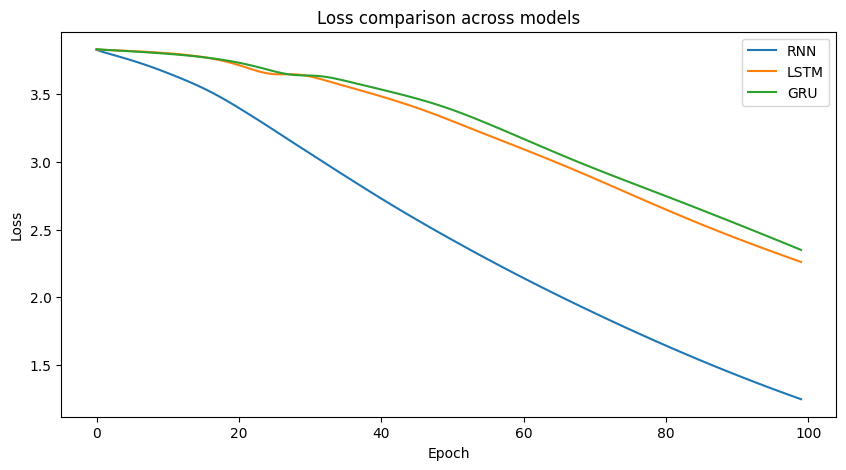

In [9]:
plt.figure(figsize=(10,5))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss comparison across models')
plt.legend()
plt.show()

In [10]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        tokens = tokenizer.texts_to_sequences([seed_text])[0]
        tokens = pad_sequences([tokens], maxlen=max_len-1, padding='pre')
        pred = np.argmax(model.predict(tokens, verbose=0), axis=-1)[0]
        word = ""

        for w, index in tokenizer.word_index.items():
            if index == pred:
                word = w
                break
        seed_text += " " + word

    return seed_text

In [11]:
seed = "the sun"
print("RNN :", generate_text(rnn_model, seed, 5))
print("LSTM:", generate_text(lstm_model, seed, 5))
print("GRU :", generate_text(gru_model, seed, 5))

RNN : the sun slowly slowly alive the quiet
LSTM: the sun slowly slowly the orange and
GRU : the sun slowly comes the the and


## Retry with 200 epochs

In [12]:
corpus2 = """
technology keeps changing the way people live and work every single day
new ideas in artificial intelligence are shaping industries across the world
students today learn coding and data skills much earlier than before
companies use machine learning to understand customers and improve products
the future of work depends heavily on how fast people adapt to change
"""
print(corpus2)


technology keeps changing the way people live and work every single day
new ideas in artificial intelligence are shaping industries across the world
students today learn coding and data skills much earlier than before
companies use machine learning to understand customers and improve products
the future of work depends heavily on how fast people adapt to change



In [13]:
tokenizer2 = Tokenizer()
tokenizer2.fit_on_texts([corpus2])
total_words2 = len(tokenizer2.word_index) + 1

input_sequences2 = []
for line in corpus2.split("\n"):
    if line.strip() == "":
        continue
    tokens = tokenizer2.texts_to_sequences([line])[0]
    for i in range(1, len(tokens)):
        input_sequences2.append(tokens[:i+1])

In [14]:
max_len2 = max(len(x) for x in input_sequences2)
input_sequences2 = pad_sequences(input_sequences2, maxlen=max_len2, padding='pre')

X2 = input_sequences2[:, :-1]
y2 = input_sequences2[:, -1]
print(X2.shape, y2.shape)

(52, 12) (52,)


In [15]:
rnn_model2 = Sequential([
    Embedding(total_words2, 64, input_length=max_len2-1),
    SimpleRNN(128),
    Dense(total_words2, activation='softmax')
])
rnn_model2.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
rnn_history2 = rnn_model2.fit(X2, y2, epochs=200, verbose=0)

In [16]:
lstm_model2 = Sequential([
    Embedding(total_words2, 64, input_length=max_len2-1),
    LSTM(128),
    Dense(total_words2, activation='softmax')
])
lstm_model2.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
lstm_history2 = lstm_model2.fit(X2, y2, epochs=200, verbose=0)

In [17]:
gru_model2 = Sequential([
    Embedding(total_words2, 64, input_length=max_len2-1),
    GRU(128),
    Dense(total_words2, activation='softmax')
])
gru_model2.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
gru_history2 = gru_model2.fit(X2, y2, epochs=200, verbose=0)

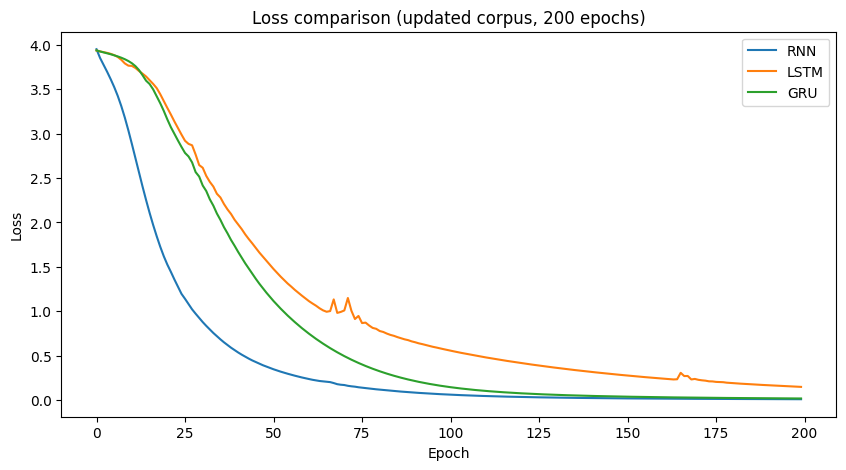

In [18]:
plt.figure(figsize=(10,5))
plt.plot(rnn_history2.history['loss'], label='RNN')
plt.plot(lstm_history2.history['loss'], label='LSTM')
plt.plot(gru_history2.history['loss'], label='GRU')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss comparison (updated corpus, 200 epochs)')
plt.legend()
plt.show()

In [19]:
def generate_text2(model, tok, seed_text, next_words=10):
    for _ in range(next_words):
        tokens = tok.texts_to_sequences([seed_text])[0]
        tokens = pad_sequences([tokens], maxlen=max_len2-1, padding='pre')
        pred = np.argmax(model.predict(tokens, verbose=0), axis=-1)[0]
        word = ""

        for w, index in tok.word_index.items():
            if index == pred:
                word = w
                break
        seed_text += " " + word

    return seed_text

In [27]:
seed2 = "technology keeps"
print("RNN :", generate_text2(rnn_model2, tokenizer2, seed2, 10))
print("LSTM:", generate_text2(lstm_model2, tokenizer2, seed2, 10))
print("GRU :", generate_text2(gru_model2, tokenizer2, seed2, 10))

RNN : technology keeps changing the way people live and work every single day
LSTM: technology keeps changing the way people live and work every single day
GRU : technology keeps changing the way people live and work every single day


In [28]:
seed2 = "artificial intelligence"
print("RNN :", generate_text2(rnn_model2, tokenizer2, seed2, 7))
print("LSTM:", generate_text2(lstm_model2, tokenizer2, seed2, 7))
print("GRU :", generate_text2(gru_model2, tokenizer2, seed2, 7))

RNN : artificial intelligence future of work depends the on people
LSTM: artificial intelligence ideas in intelligence are shaping industries across
GRU : artificial intelligence changing the way people live and work


In [29]:
seed2 = "machine learning"
print("RNN :", generate_text2(rnn_model2, tokenizer2, seed2, 5))
print("LSTM:", generate_text2(lstm_model2, tokenizer2, seed2, 5))
print("GRU :", generate_text2(gru_model2, tokenizer2, seed2, 5))

RNN : machine learning today learn coding and data
LSTM: machine learning use learning to understand customers
GRU : machine learning machine learning to understand customers
